## State Schema with DataClasses

When we define a LangGraph StateGraph, we use a state schema

The state schema represents the structure and types of data that our graph will use.

All nodes are expected to communicate with that schema.

### **TypedDict** Way

Flaw: In TypedDict the variable is not forced at runtime which means we can write a `int` value in variable as it is assigned to `str`

In [19]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    game: Literal["cricket", "football"]

In [20]:
def play_game(state: TypedDictState):
     print('---Play Game node has been called---')
     return {"name": state['name'] + " " + "wants to play"}

def cricket(state: TypedDictState):
     print('---Cricket Node has been called---')
     return {"name": state['name'] +" " + "cricket", "game": "cricket"}

def football(state: TypedDictState):
     print('---Football Node has been called---')
     return {"name": state['name'] +" " + "football", "game": "football"}

In [21]:
import random
def decide_play(state: TypedDictState) -> Literal['cricket', 'football']:
    if random.random() > 0.5:
        return "cricket"
    else:
        return "football"

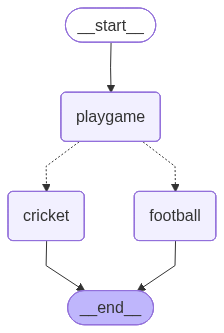

In [22]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TypedDictState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("football", football)

## Flow of the Graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("football", END)

## Compile
graph = builder.compile()

# Display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
graph.invoke({'name': 'Navneet'})

---Play Game node has been called---
---Football Node has been called---


{'name': 'Navneet wants to play football', 'game': 'football'}

## DataClasses

Python's Dataclasses provide another way to define structured data.

It also has the same flaw as the TypedDict

In [24]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name: str
    game: Literal['cricket', 'football']

In [25]:
def play_game(state: DataClassState):
     print('---Play Game node has been called---')
     return {"name": state.name + " " + "wants to play"}

def cricket(state: DataClassState):
     print('---Cricket Node has been called---')
     return {"name": state.name +" " + "cricket", "game": "cricket"}

def football(state: DataClassState):
     print('---Football Node has been called---')
     return {"name": state.name +" " + "football", "game": "football"}

In [26]:
import random
def decide_play(state: DataClassState) -> Literal['cricket', 'football']:
    if random.random() > 0.5:
        return "cricket"
    else:
        return "football"

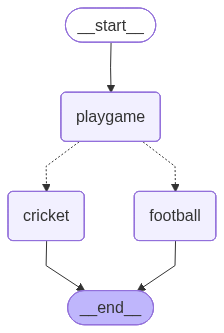

In [27]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(DataClassState)
builder.add_node("playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("football", football)

## Flow of the Graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("cricket", END)
builder.add_edge("football", END)

## Compile
graph = builder.compile()

# Display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
graph.invoke(DataClassState(name= "Navneet", game= "cricket"))

---Play Game node has been called---
---Football Node has been called---


{'name': 'Navneet wants to play football', 'game': 'football'}